In [ ]:
%cd ..
import tangramlit as tg

In [ ]:
import scanpy as sc

In [ ]:
!uv pip install winshell

In [39]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")

Real path: H:\.shortcut-targets-by-id\1UGLL2UOn-9s1OY1r9mGMc1RFF7REij9e\dati_per_enrico
Resolved path is accessible


# Data loading

In [27]:
## Load pre-processed datasets
path = "H:/Il mio Drive"
adata_sc = sc.read_h5ad(path + "/data_tangram/counts100k_filt_pp_train_genes.h5ad")
adata_sc

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe', 'sparsity'
    uns: 'hvg', 'neighbors', 'pca', 'training_genes', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [28]:
adata_st = sc.read_h5ad(path + "/data_tangram/slice200_pp.h5ad")
adata_st

AnnData object with n_obs × n_vars = 2133 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

# Baseline Model

In [33]:
ad_map_baseline_filt, mapper_filt, data_filt = tg.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='filter',
    learning_rate=0.1,
    num_epochs=10,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1,
    lambda_f_reg=1,
    target_count=None,
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 4.6 M  | n/a  
---------------------------------------------------------
4.6 M     Trainable params
0         Non-trainable params
4.6 M     Total params
18.395    Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                  | 0/10 [00:00<?, ?it/s]

Training with 254 genes
S matrix shape: torch.Size([2155, 254])
G matrix shape: torch.Size([2133, 254])


Trainig:  10%|███████▍                                                                  | 1/10 [00:00<00:04,  1.90it/s]

Epoch 0: {'Total loss': 1497.6221923828125, 'Score': 0.515012264251709, 'KL divergence': 0.00048210308887064457, 'Filter term': 1055.7230224609375}


Trainig: 100%|█████████████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.49it/s]


Initial value of total_loss 1497.6221923828125
Initial value of main_loss 0.515012264251709
Initial value of vg_reg 0.5858179926872253
Initial value of kl_reg 0.00048210308887064457
Initial value of entropy_reg -0.0
Initial value of l1_term 0.0
Initial value of l2_term 0.0
Initial value of count_reg 1055.7230224609375
Initial value of lambda_f_reg 442.99951171875


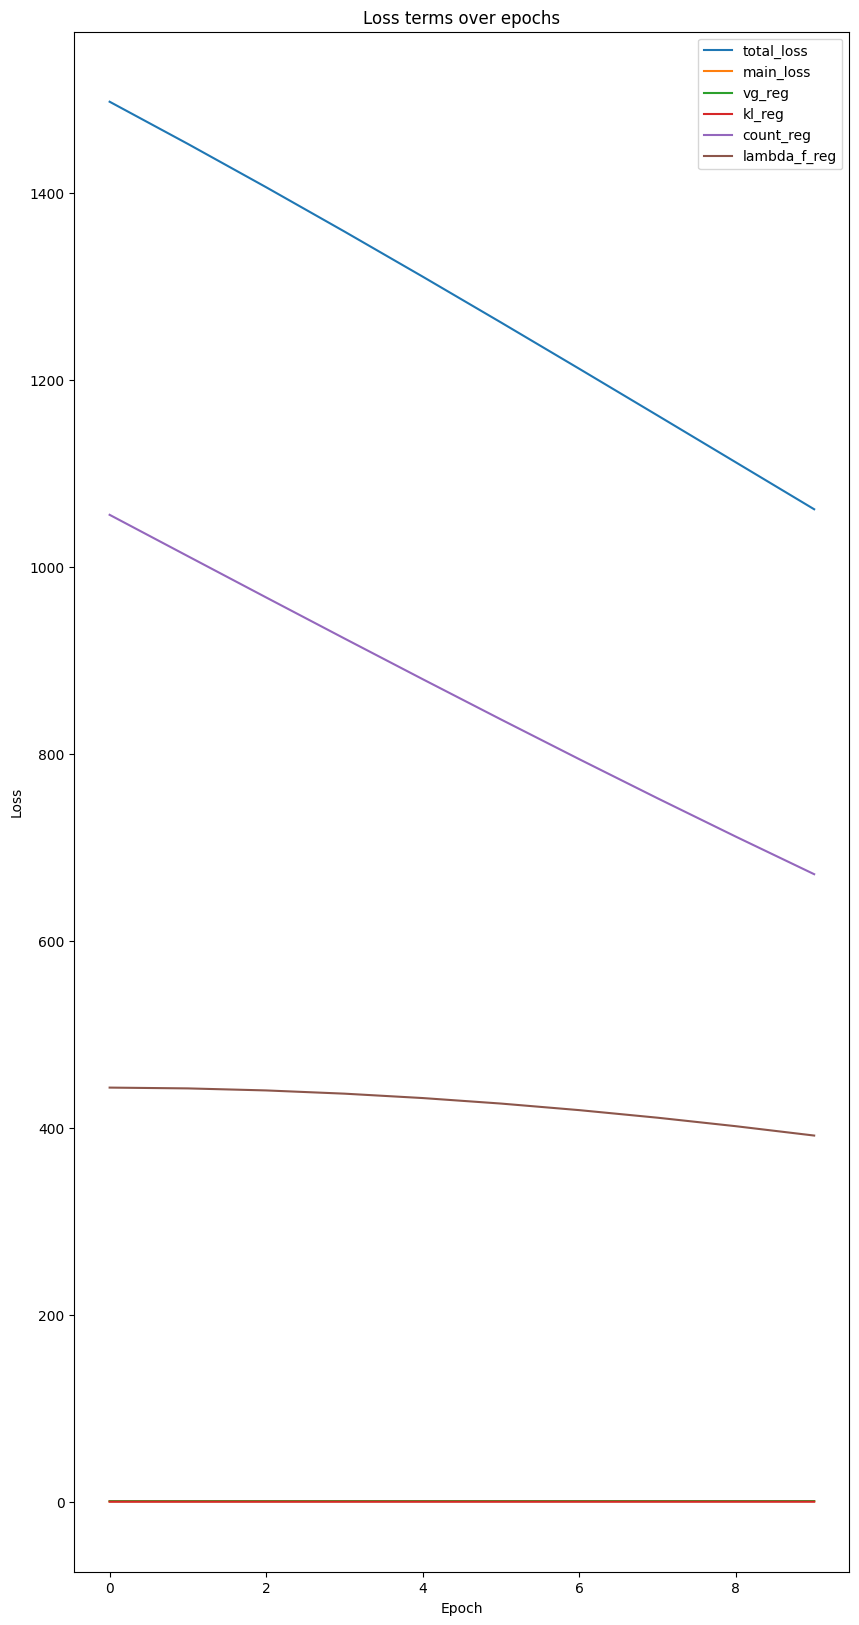

In [34]:
# Plot loss terms
for term in ad_map_baseline_filt.uns['training_history'].keys():
    value = ad_map_baseline_filt.uns['training_history'][term][0]
    print("Initial value of", term, value)
    
tg.plot_training_history(adata_map=ad_map_baseline_filt, hyperpams=mapper_filt.hparams,
                   log_scale=False, lambda_scale=False)

Same here with very distant scales. Filter terms are on a different scales, compared to everything else.

# Model Analysis
A model with proper hyperparameters is now trained and its results analyzed.

To avoid introducing confusion, we first activate the filter mode while simultaneously deactivating the regularizers acting on the mapping matrix $M$.

We might reintroduce later the entropy regularizer to explore any possible regularazing action combined with filtering.

In [ ]:
ad_map_filt, mapper_filt, datamodule_filt = tg.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='filter',
    num_epochs=500,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-4,
    lambda_f_reg=1e-3,
    random_state=42,
    )

In [ ]:
# Plot loss terms
tg.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, log_scale=False)

In [ ]:
# Plot main loss
tg.plot_loss_term(adata_map=ad_map_filt, loss_key="main_loss", lambda_scale=False)
# Plot voxels/genes term
tg.plot_loss_term(adata_map=ad_map_filt, loss_key="vg_reg", lambda_scale=False)

## Filter ICs
In this section we asses whether the IC of the filter affect its final values and, if so, how much. 

One way to see this is to check if the filter values of the cells that are "selected" at the end (have high confidence) correlate to ther initial values, i.e. if the initial values biases the selection.

In [ ]:
# Plot final filter values distribution
tg.plot_filter_weights(ad_map_filt, plot_spaghetti=True, plot_envelope=False)
tg.plot_filter_count(ad_map_filt, target_count=None)

In [ ]:
filt_corr = tg.compute_filter_corr(ad_map_filt)

In [ ]:
filt_sim = tg.compute_mapped_similarity(ad_map_filt, adata_sc, adata_st, 
                                       flavour='spot_to_cell', filter=True)

In [58]:
print(adata_sc.obs.keys())
print(adata_st.obs.keys())

Index(['sample_id', 'slice_id', 'class_label', 'subclass', 'label',
       'instance_id', 'centroid_x', 'centroid_y', 'region'],
      dtype='object')
Index(['sample_id', 'slice_id', 'class_label', 'subclass', 'label',
       'instance_id', 'centroid_x', 'centroid_y', 'region'],
      dtype='object')


In [ ]:
filt_acc = tg.compute_annotation_accuracy(
        ad_map_filt,
        adata_sc,
        adata_st,
        flavour='spot_to_cell',
        sc_cluster_label='Allen.subclass_label',
        st_cluster_label='subclass',
        filter=True,
)